In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import sys
sys.path.append("..")

import random
random.seed(9001)

In [5]:
from PyPOTS_gp_benchmark_helpers import artifical_GP_generation

dataset_train_nan, dataset_val_nan, dataset_train, dataset_val, X_normalized, X = artifical_GP_generation(n_observations_per_group = 500,
                                                n_dimensions = 3,
                                                n_time_points = 30,
                                                n_new_dims = 7,
                                                p_dataset = 0.5)

100%|██████████| 500/500 [00:00<00:00, 2027.79it/s]


In [6]:
dataset_train_nan['X'][0,0]

array([       nan,        nan,        nan, 0.77241868, 0.4517692 ,
              nan,        nan])

In [7]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GP_UAE
from pypots.utils.metrics import calc_mae
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

gpuae = GP_UAE(n_steps = dataset_train['X'].shape[1], 
            n_features = dataset_train['X'].shape[2], 
            latent_size = 6, 
            epochs = 2000, 
            batch_size = 64,
            alpha = .9,
            beta = .01, 
            sigma = 1e-2,
            K = 1,  
            encoder_sizes = (32,64,), 
            decoder_sizes = (64,32,),
            optimizer = Adam(weight_decay=0.001), #lr = 1e-4
            patience = 100,
            p = 0.3
            )

gpuae.use_gp = False
gpuae.train_gp = False
gpuae.gp.plot_while_training = True
gpuae.model.backbone.device = 'cpu'
gpuae.model.backbone.encoder.pre_impute = False
gpuae.model.backbone.DAE = False
gpuae.model.backbone.kl_weight = 1

import torch
with torch.autograd.set_detect_anomaly(True):
    gpuae.fit(dataset_train_nan, dataset_val_nan)  # train the model on the dataset

/Users/vincente/Documents/Vie Pro/Phd/Code/Code_pour_manuscript/PyPOTS/ipynbs/../pypots/nn/modules/reformer/local_attention.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/Users/vincente/Documents/Vie Pro/Phd/Code/Code_pour_manuscript/PyPOTS/ipynbs/../pypots/nn/modules/reformer/local_attention.py:98: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
2026-03-09 13:48:38 [INFO]: No given device, using default device: cpu
2026-03-09 13:48:38 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2026-03-09 13:48:38 [INFO]: GP_UAE initialized with the given hyperparameters, the number of trainable parameters: 6,131



████████╗██╗███╗   ███╗███████╗    ███████╗███████╗██████╗ ██╗███████╗███████╗    █████╗ ██╗
╚══██╔══╝██║████╗ ████║██╔════╝    ██╔════╝██╔════╝██╔══██╗██║██╔════╝██╔════╝   ██╔══██╗██║
   ██║   ██║██╔████╔██║█████╗█████╗███████╗█████╗  ██████╔╝██║█████╗  ███████╗   ███████║██║
   ██║   ██║██║╚██╔╝██║██╔══╝╚════╝╚════██║██╔══╝  ██╔══██╗██║██╔══╝  ╚════██║   ██╔══██║██║
   ██║   ██║██║ ╚═╝ ██║███████╗    ███████║███████╗██║  ██║██║███████╗███████║██╗██║  ██║██║
   ╚═╝   ╚═╝╚═╝     ╚═╝╚══════╝    ╚══════╝╚══════╝╚═╝  ╚═╝╚═╝╚══════╝╚══════╝╚═╝╚═╝  ╚═╝╚═╝
ai4ts v0.0.3 - building AI for unified time-series analysis, https://time-series.ai 

Model dimensions is:
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=14, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
  )
  (mu_layer): Linear(in_features=64, out_features=6, bias=True)
  (logvar_layer): Linear(in_features=64, out_features=6

2026-03-09 13:48:39 [INFO]: Epoch 001 - training loss: 49.5781, validation loss: 51.8408
2026-03-09 13:48:39 [INFO]: Epoch 002 - training loss: 47.4437, validation loss: 50.3686
2026-03-09 13:48:39 [INFO]: Epoch 003 - training loss: 47.4683, validation loss: 50.1299
2026-03-09 13:48:40 [INFO]: Epoch 004 - training loss: 46.1768, validation loss: 48.5235
2026-03-09 13:48:40 [INFO]: Epoch 005 - training loss: 43.6553, validation loss: 45.2841
2026-03-09 13:48:41 [INFO]: Epoch 006 - training loss: 39.0295, validation loss: 37.6648
2026-03-09 13:48:41 [INFO]: Epoch 007 - training loss: 30.8737, validation loss: 27.4972
2026-03-09 13:48:41 [INFO]: Epoch 008 - training loss: 21.4554, validation loss: 19.6367
2026-03-09 13:48:42 [INFO]: Epoch 009 - training loss: 17.8114, validation loss: 16.7107
2026-03-09 13:48:42 [INFO]: Epoch 010 - training loss: 15.1941, validation loss: 14.2052
2026-03-09 13:48:42 [INFO]: Epoch 011 - training loss: 13.2127, validation loss: 13.7411
2026-03-09 13:48:43 [

Plotting latent series and reconstruction...


2026-03-09 13:49:01 [INFO]: Epoch 056 - training loss: 4.0731, validation loss: 4.1589
2026-03-09 13:49:01 [INFO]: Epoch 057 - training loss: 3.9355, validation loss: 4.0853
2026-03-09 13:49:01 [INFO]: Epoch 058 - training loss: 3.9680, validation loss: 4.1180
2026-03-09 13:49:02 [INFO]: Epoch 059 - training loss: 3.8756, validation loss: 4.0376
2026-03-09 13:49:02 [INFO]: Epoch 060 - training loss: 3.8170, validation loss: 3.9362
2026-03-09 13:49:02 [INFO]: Epoch 061 - training loss: 3.8266, validation loss: 3.7677
2026-03-09 13:49:03 [INFO]: Epoch 062 - training loss: 3.7671, validation loss: 3.8987
2026-03-09 13:49:03 [INFO]: Epoch 063 - training loss: 3.5975, validation loss: 3.8084
2026-03-09 13:49:03 [INFO]: Epoch 064 - training loss: 3.5600, validation loss: 3.6582
2026-03-09 13:49:04 [INFO]: Epoch 065 - training loss: 3.5332, validation loss: 3.6751
2026-03-09 13:49:04 [INFO]: Epoch 066 - training loss: 3.5975, validation loss: 3.6129
2026-03-09 13:49:04 [INFO]: Epoch 067 - tra

...

2026-03-09 13:52:30 [INFO]: Epoch 612 - training loss: 0.5153, validation loss: 0.3822
2026-03-09 13:52:30 [INFO]: Epoch 613 - training loss: 0.4945, validation loss: 0.3614
2026-03-09 13:52:31 [INFO]: Epoch 614 - training loss: 0.4787, validation loss: 0.3993
2026-03-09 13:52:31 [INFO]: Epoch 615 - training loss: 0.5022, validation loss: 0.4094
2026-03-09 13:52:31 [INFO]: Epoch 616 - training loss: 0.5109, validation loss: 0.3868
2026-03-09 13:52:32 [INFO]: Epoch 617 - training loss: 0.4890, validation loss: 0.3878
2026-03-09 13:52:32 [INFO]: Epoch 618 - training loss: 0.4655, validation loss: 0.4009
2026-03-09 13:52:32 [INFO]: Epoch 619 - training loss: 0.4958, validation loss: 0.3846
2026-03-09 13:52:32 [INFO]: Epoch 620 - training loss: 0.5031, validation loss: 0.4012
2026-03-09 13:52:33 [INFO]: Epoch 621 - training loss: 0.4723, validation loss: 0.3605
2026-03-09 13:52:33 [INFO]: Epoch 622 - training loss: 0.4927, validation loss: 0.3848
2026-03-09 13:52:34 [INFO]: Epoch 623 - tra

Plotting latent series and reconstruction...


2026-03-09 13:52:49 [INFO]: Epoch 667 - training loss: 0.4759, validation loss: 0.3796
2026-03-09 13:52:49 [INFO]: Epoch 668 - training loss: 0.4778, validation loss: 0.3754
2026-03-09 13:52:50 [INFO]: Epoch 669 - training loss: 0.4681, validation loss: 0.4145
2026-03-09 13:52:50 [INFO]: Epoch 670 - training loss: 0.4669, validation loss: 0.3674
2026-03-09 13:52:50 [INFO]: Epoch 671 - training loss: 0.4823, validation loss: 0.3670
2026-03-09 13:52:50 [INFO]: Epoch 672 - training loss: 0.4824, validation loss: 0.3477
2026-03-09 13:52:51 [INFO]: Epoch 673 - training loss: 0.4910, validation loss: 0.3841
2026-03-09 13:52:51 [INFO]: Epoch 674 - training loss: 0.4954, validation loss: 0.3536
2026-03-09 13:52:52 [INFO]: Epoch 675 - training loss: 0.4790, validation loss: 0.3806
2026-03-09 13:52:52 [INFO]: Epoch 676 - training loss: 0.4726, validation loss: 0.3858
2026-03-09 13:52:52 [INFO]: Epoch 677 - training loss: 0.4604, validation loss: 0.3688
2026-03-09 13:52:53 [INFO]: Epoch 678 - tra

Plotting latent series and reconstruction...


2026-03-09 13:53:09 [INFO]: Epoch 723 - training loss: 0.4696, validation loss: 0.3535
2026-03-09 13:53:09 [INFO]: Epoch 724 - training loss: 0.4675, validation loss: 0.3755
2026-03-09 13:53:10 [INFO]: Epoch 725 - training loss: 0.4520, validation loss: 0.3825
2026-03-09 13:53:10 [INFO]: Epoch 726 - training loss: 0.4557, validation loss: 0.3661
2026-03-09 13:53:10 [INFO]: Epoch 727 - training loss: 0.4702, validation loss: 0.3566
2026-03-09 13:53:11 [INFO]: Epoch 728 - training loss: 0.4592, validation loss: 0.3692
2026-03-09 13:53:11 [INFO]: Epoch 729 - training loss: 0.4609, validation loss: 0.3470
2026-03-09 13:53:11 [INFO]: Epoch 730 - training loss: 0.4745, validation loss: 0.3466
2026-03-09 13:53:12 [INFO]: Epoch 731 - training loss: 0.4706, validation loss: 0.3510
2026-03-09 13:53:12 [INFO]: Epoch 732 - training loss: 0.4731, validation loss: 0.3470
2026-03-09 13:53:12 [INFO]: Epoch 733 - training loss: 0.4770, validation loss: 0.3496
2026-03-09 13:53:13 [INFO]: Epoch 734 - tra

tensor(0.7410)
tensor(0.0333, grad_fn=<MeanBackward0>) tensor(inf, grad_fn=<MeanBackward0>)


2026-03-09 13:56:29 [ERROR]: ❌ Exception: Expected parameter loc (Tensor of shape (64, 30, 6)) of distribution Normal(loc: torch.Size([64, 30, 6]), scale: torch.Size([64, 30, 6])) to satisfy the constraint Real(), but found invalid values:
tensor([[[nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan],
         ...,
         [nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan]],

        [[nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan],
         ...,
         [nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan]],

        [[nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan],
         ...,
         [nan, nan, nan, nan, nan, nan],
         [nan, nan, nan, nan, nan, nan],
         [nan, na

RuntimeError: Training got interrupted. Model was not trained. Please investigate the error printed above.

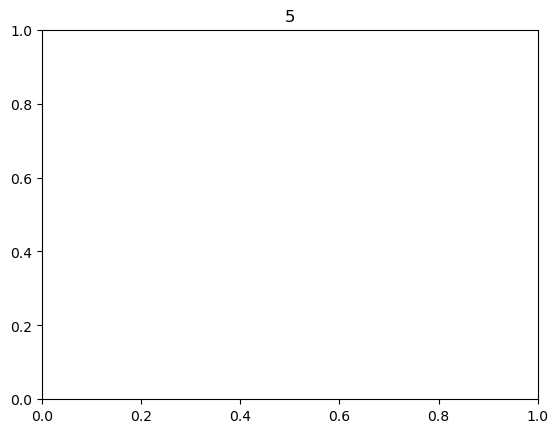

In [16]:
gpuae.model.backbone.alpha = 0.1
gpuae.use_gp = True
gpuae.train_gp = True
gpuae.fit(dataset_train_nan, dataset_val_nan)  # train the model on the dataset

training kernel


0it [00:00, ?it/s]

tensor(0.7433)
0.028765251860022545 0.22493425011634827


1it [00:00,  3.49it/s]

tensor(0.7428)
0.0318986251950264 0.2065275013446808


...

4it [00:01,  2.85it/s]

tensor(0.7389)
0.03304758667945862 0.21586973965168


6it [00:01,  3.13it/s]

tensor(0.7409)
0.02796105109155178 0.1836683303117752
tensor(0.7454)


torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7410)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7414)
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])
tensor(0.6965)


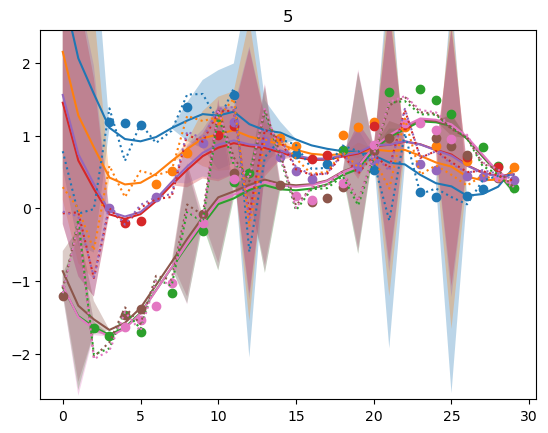

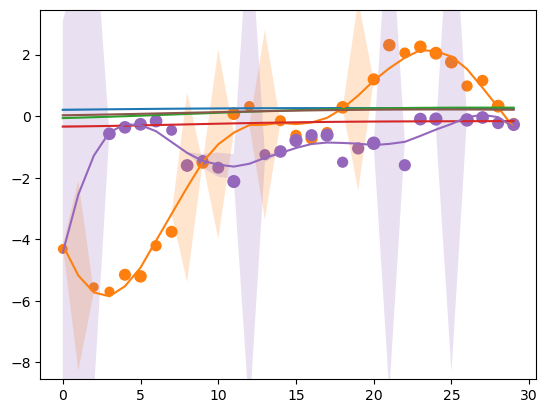

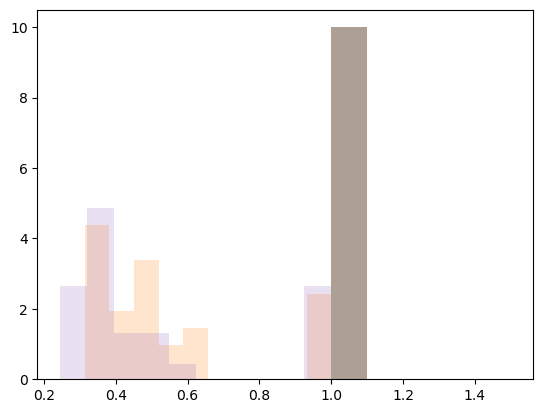

Epoch 2/2000: Training Loss = 0.221802, Validation Loss = 0.065821


0it [00:00, ?it/s]

tensor(0.7401)
0.03217221796512604 0.18912139534950256


1it [00:00,  3.28it/s]

tensor(0.7419)


...

0.02865973673760891 0.20048770308494568
tensor(0.7413)


5it [00:01,  3.30it/s]

0.02934105135500431 0.17078128457069397
tensor(0.7409)
0.03493720665574074 0.2102057784795761


6it [00:01,  3.43it/s]


tensor(0.7456)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7424)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7442)
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])
tensor(0.6967)


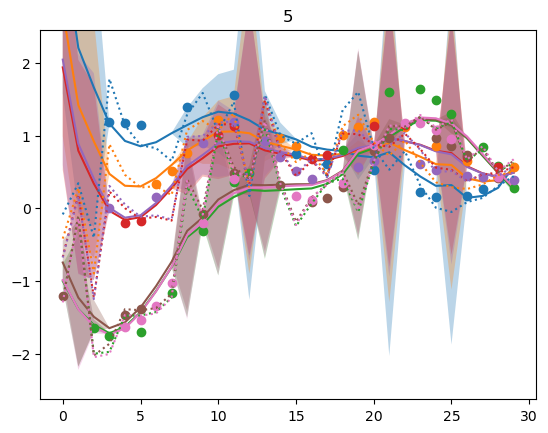

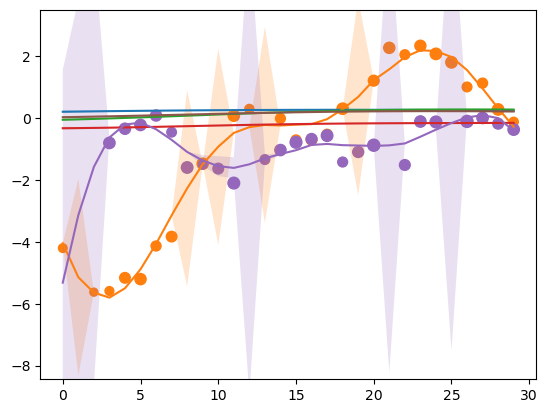

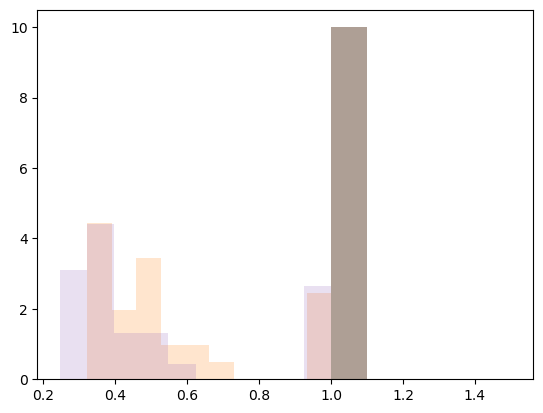

Epoch 3/2000: Training Loss = 0.214739, Validation Loss = 0.065180


0it [00:00, ?it/s]

tensor(0.7437)


1it [00:00,  1.36it/s]

0.03147042542695999 0.19079680740833282
tensor(0.7392)
0.029866019263863564 0.19631624221801758


...

0.027701815590262413 0.19717341661453247
tensor(0.7418)


5it [00:01,  3.82it/s]

0.029856782406568527 0.21920259296894073
tensor(0.7441)


6it [00:01,  3.48it/s]


0.034476105123758316 0.21975144743919373
tensor(0.7427)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7429)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7379)
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])
tensor(0.6962)


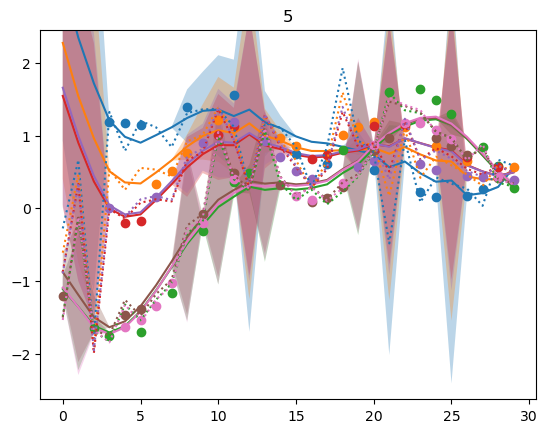

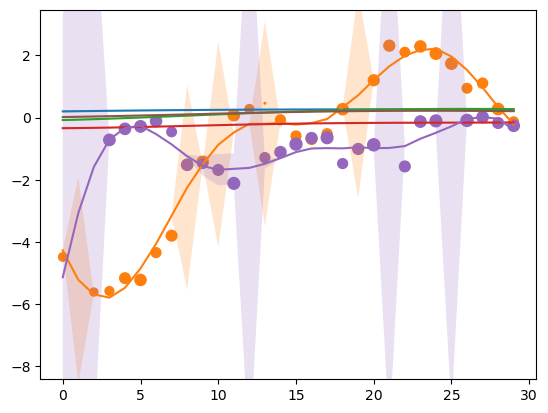

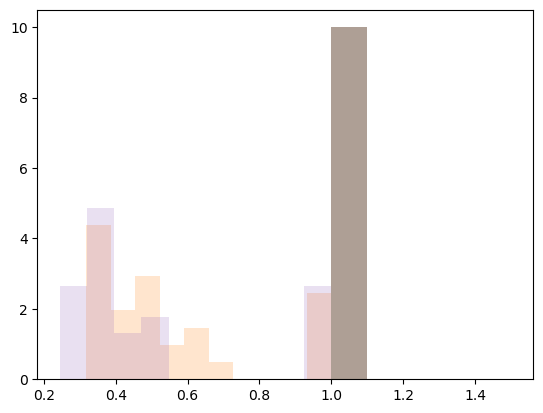

Epoch 4/2000: Training Loss = 0.212529, Validation Loss = 0.066470


0it [00:00, ?it/s]

tensor(0.7375)
0.030537491664290428 0.18543046712875366


1it [00:00,  3.02it/s]

tensor(0.7426)
0.03216136246919632 0.20758233964443207


...

tensor(0.7384)
0.026991166174411774 0.23708009719848633


5it [00:01,  3.42it/s]

tensor(0.7483)
0.029348570853471756 0.2525267004966736


6it [00:01,  3.75it/s]


tensor(0.7459)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7391)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7455)
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])
tensor(0.6965)


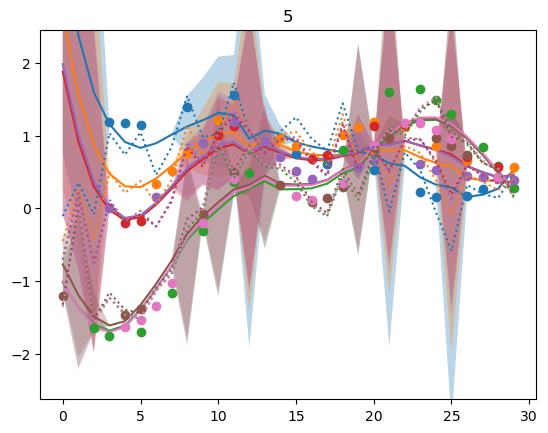

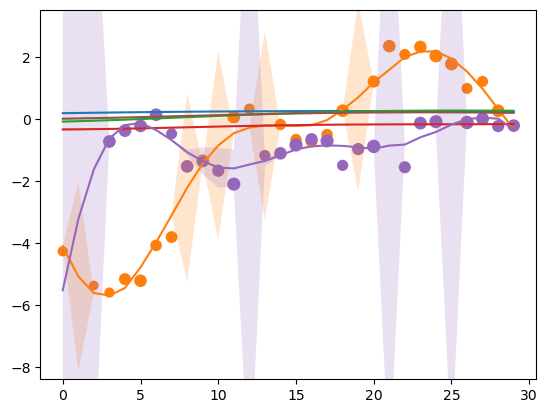

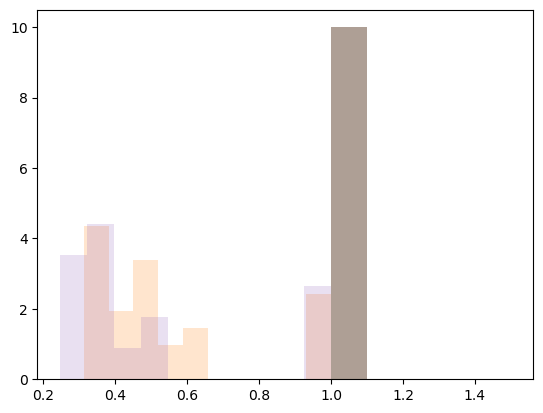

Epoch 5/2000: Training Loss = 0.213833, Validation Loss = 0.069396


0it [00:00, ?it/s]

tensor(0.7401)
0.02892228402197361 0.22017236053943634


1it [00:00,  3.09it/s]

tensor(0.7451)
0.028434984385967255 0.22781230509281158


...

tensor(0.7409)
0.030849408358335495 0.22144490480422974


4it [00:01,  2.74it/s]

tensor(0.7361)
0.03010537289083004 0.20795407891273499


6it [00:01,  3.31it/s]


tensor(0.7481)
0.03384925052523613 0.25394901633262634
tensor(0.7432)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7426)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7386)
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])
tensor(0.6962)


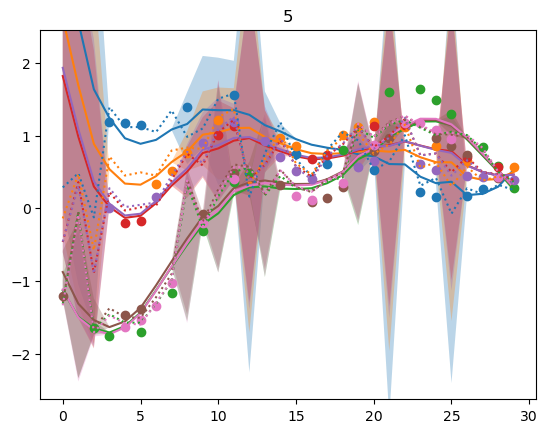

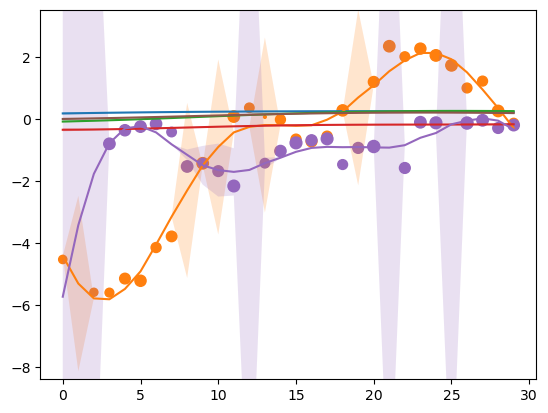

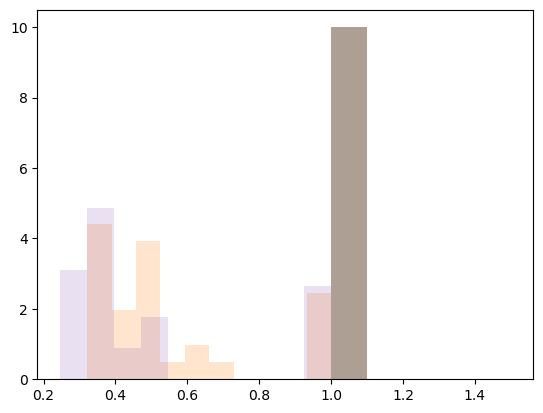

Epoch 6/2000: Training Loss = 0.210489, Validation Loss = 0.071431


0it [00:00, ?it/s]

tensor(0.7401)
0.02859160490334034 0.23990805447101593


1it [00:00,  3.13it/s]

tensor(0.7445)
0.032580964267253876 0.2397889643907547


...

tensor(0.7424)
0.029003173112869263 0.26257234811782837


4it [00:01,  3.29it/s]

tensor(0.7420)
0.031033609062433243 0.2498416006565094


6it [00:01,  3.65it/s]


tensor(0.7389)
0.028342444449663162 0.21764753758907318
tensor(0.7422)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7454)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7422)
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])
tensor(0.6965)


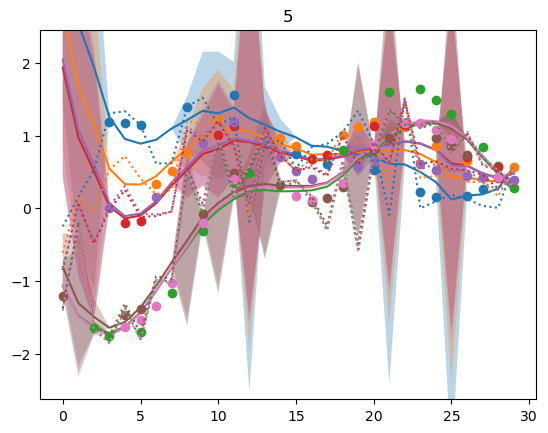

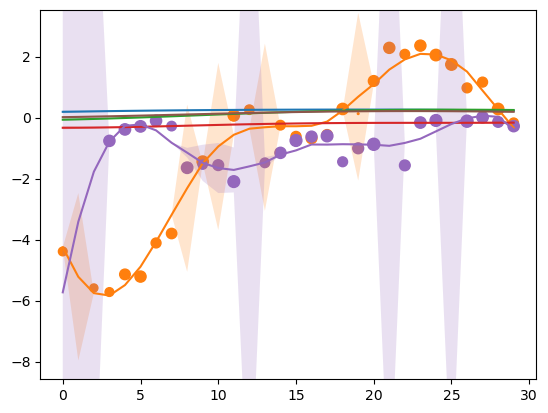

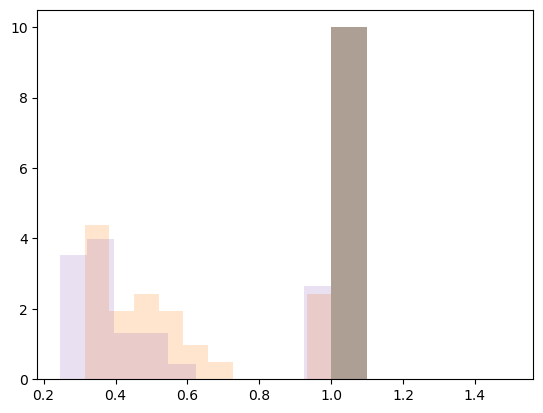

Epoch 7/2000: Training Loss = 0.210629, Validation Loss = 0.071213


0it [00:00, ?it/s]

tensor(0.7378)
0.0309157632291317 0.2250969558954239


1it [00:00,  3.89it/s]

tensor(0.7413)
0.03160976991057396 0.2224532961845398


...

tensor(0.7414)


5it [00:01,  2.95it/s]

0.028451118618249893 0.2660350799560547
tensor(0.7398)
0.03079051338136196 0.27680128812789917


6it [00:01,  3.43it/s]


tensor(0.7457)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7420)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7374)
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])
tensor(0.6965)


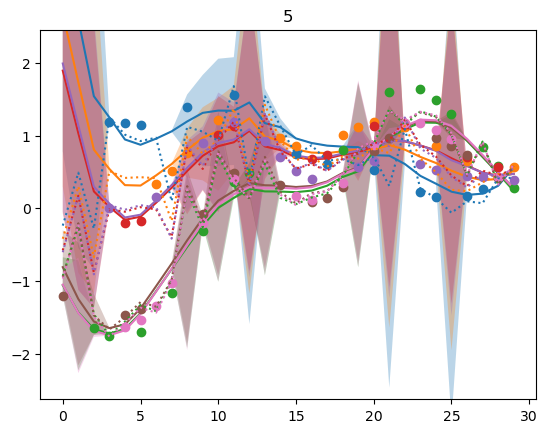

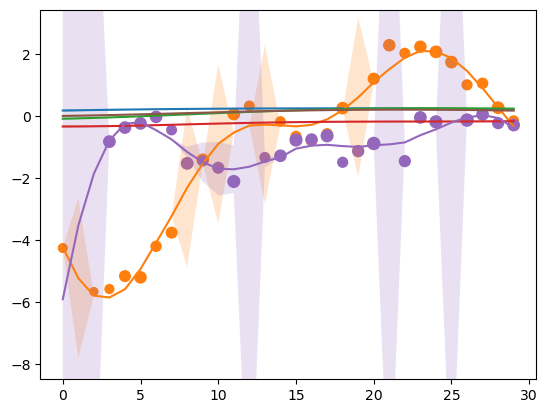

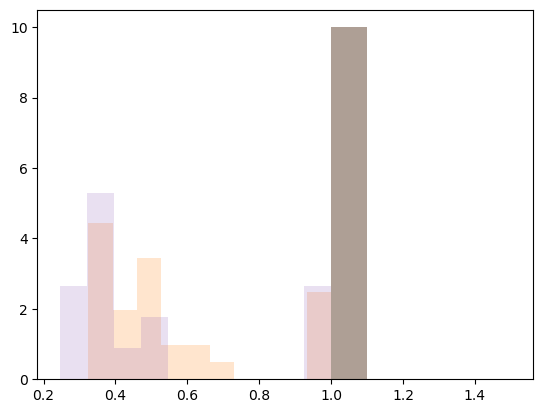

Epoch 8/2000: Training Loss = 0.208951, Validation Loss = 0.072019


0it [00:00, ?it/s]

tensor(0.7447)
0.027593940496444702 0.21855010092258453


1it [00:00,  3.72it/s]

tensor(0.7434)
0.029551051557064056 0.22526012361049652


...

tensor(0.7390)
0.033325936645269394 0.24550610780715942


4it [00:01,  3.83it/s]

tensor(0.7369)
0.030013184994459152 0.2265799343585968


6it [00:01,  4.04it/s]


tensor(0.7430)
0.027704035863280296 0.23533394932746887
tensor(0.7403)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7403)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7376)
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])
tensor(0.6965)


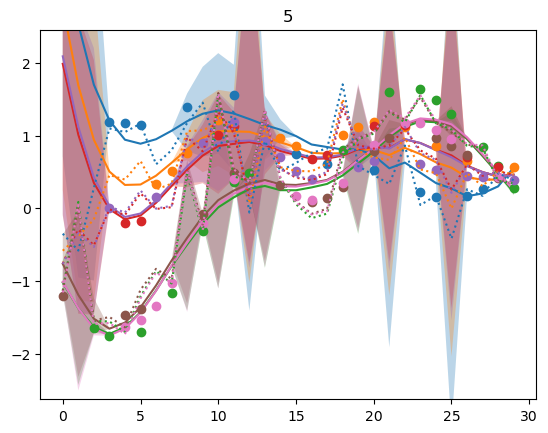

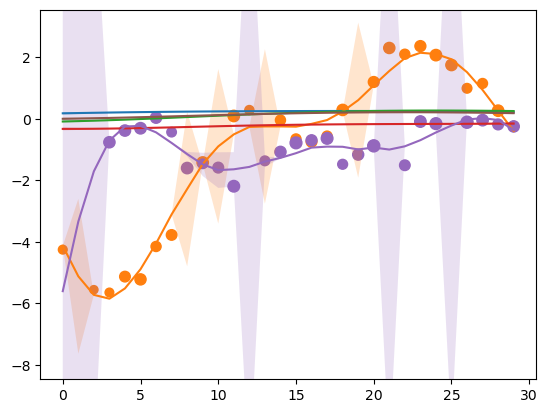

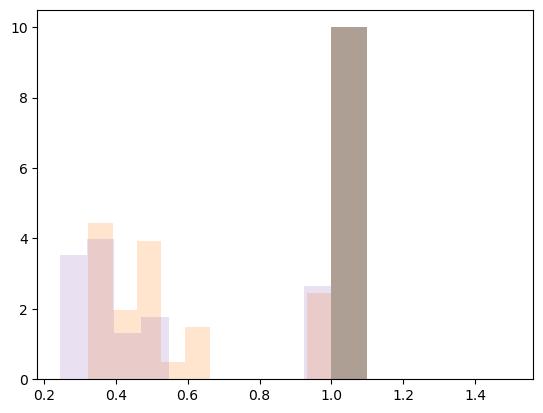

Epoch 9/2000: Training Loss = 0.200106, Validation Loss = 0.066519


0it [00:00, ?it/s]

tensor(0.7389)
0.029944662004709244 0.21123898029327393


1it [00:00,  3.42it/s]

tensor(0.7414)
0.029638098552823067 0.1958128958940506


...

tensor(0.7439)
0.030956275761127472 0.20523884892463684


4it [00:01,  3.61it/s]

tensor(0.7402)
0.02984761632978916 0.20142120122909546


6it [00:01,  3.90it/s]


tensor(0.7381)
0.03754616156220436 0.21774272620677948
tensor(0.7452)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7401)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7442)
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])
tensor(0.6965)


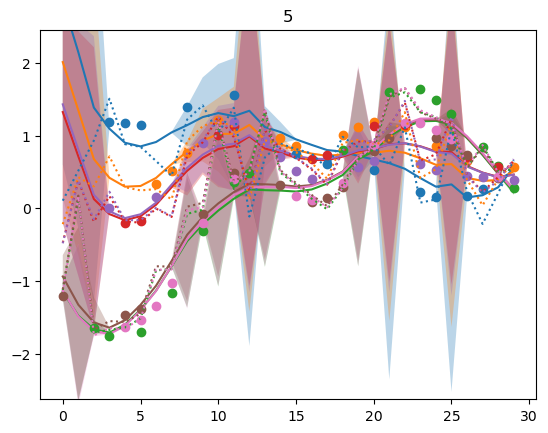

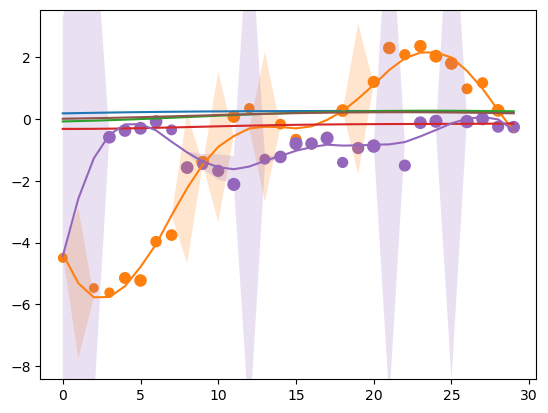

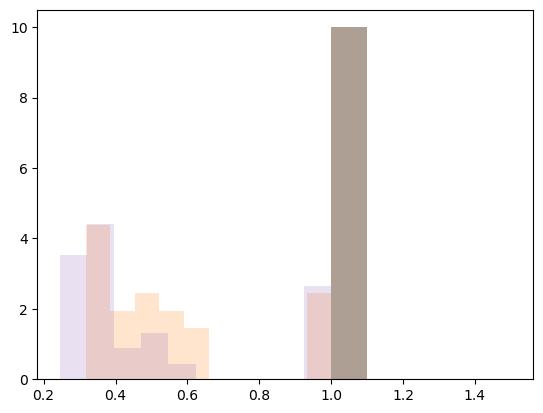

Epoch 10/2000: Training Loss = 0.193916, Validation Loss = 0.063099


0it [00:00, ?it/s]

tensor(0.7420)


1it [00:00,  2.48it/s]

0.03219671547412872 0.1899021416902542
tensor(0.7381)
0.032496415078639984 0.19031815230846405


...

tensor(0.7423)
0.028623590245842934 0.18988433480262756


5it [00:01,  3.74it/s]

tensor(0.7418)
0.028827868402004242 0.18688614666461945
tensor(0.7333)


6it [00:01,  3.66it/s]


0.027282482013106346 0.1537543386220932
tensor(0.7435)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7412)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7457)
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])
tensor(0.6962)


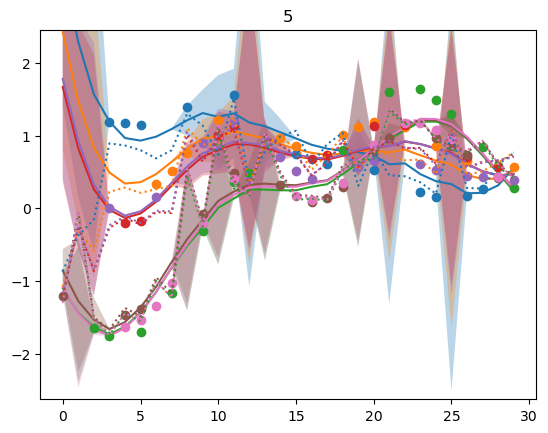

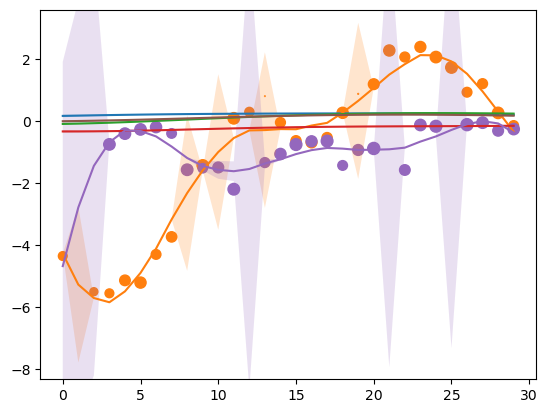

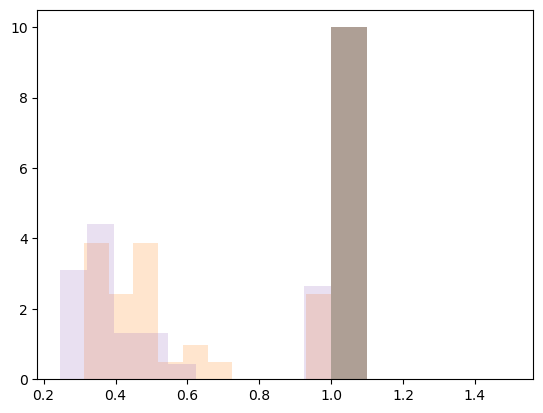

Epoch 11/2000: Training Loss = 0.185473, Validation Loss = 0.062090


0it [00:00, ?it/s]

tensor(0.7405)
0.03003421612083912 0.18150673806667328


1it [00:00,  3.25it/s]

tensor(0.7412)


...

0.03322936221957207 0.17152021825313568
tensor(0.7429)


5it [00:01,  3.07it/s]

0.028867103159427643 0.163851797580719
tensor(0.7431)


6it [00:01,  3.20it/s]


0.02675054222345352 0.16036131978034973
tensor(0.7415)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7433)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7389)
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])
tensor(0.6965)


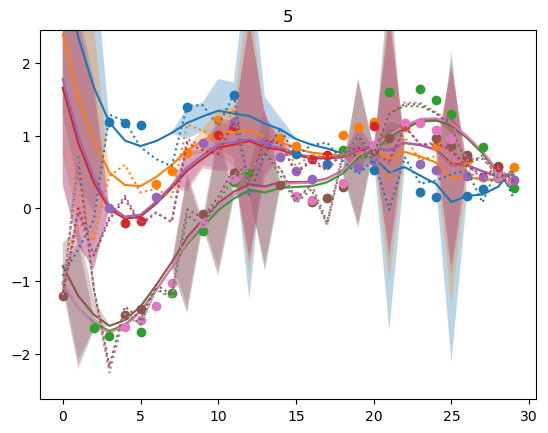

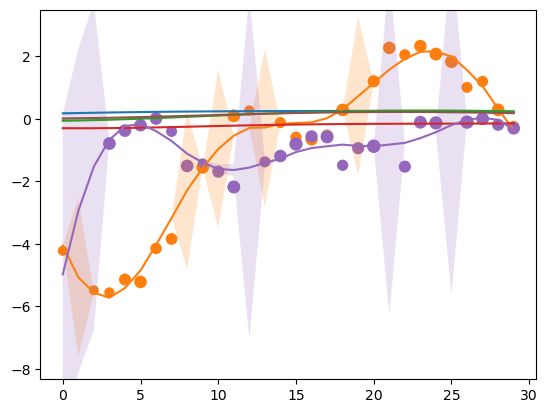

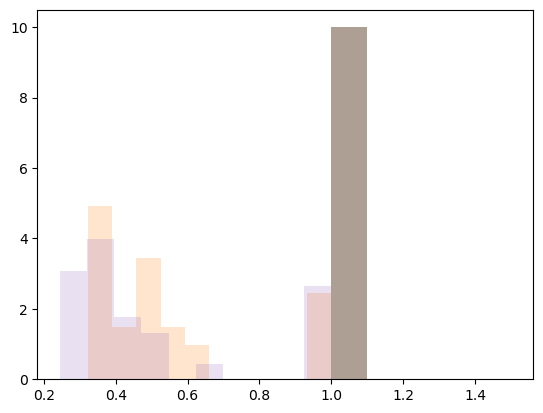

Epoch 12/2000: Training Loss = 0.182052, Validation Loss = 0.056572


0it [00:00, ?it/s]

tensor(0.7413)
0.030468327924609184 0.1837608367204666


1it [00:00,  3.27it/s]

tensor(0.7401)
0.03123258240520954 0.16725832223892212


...

tensor(0.7412)


5it [00:01,  2.80it/s]

0.03084249421954155 0.16283152997493744
tensor(0.7413)


6it [00:01,  3.32it/s]


0.02711624465882778 0.15805301070213318
tensor(0.7431)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7430)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7447)
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])
tensor(0.6962)


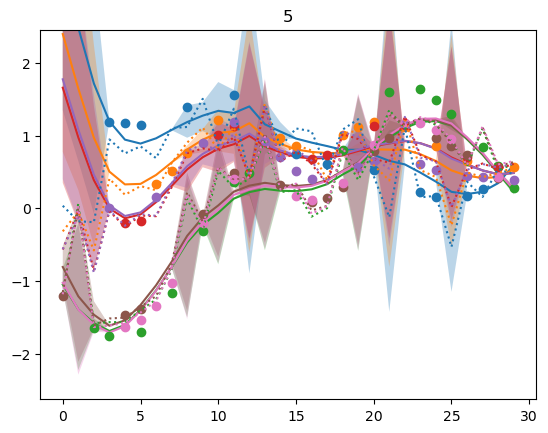

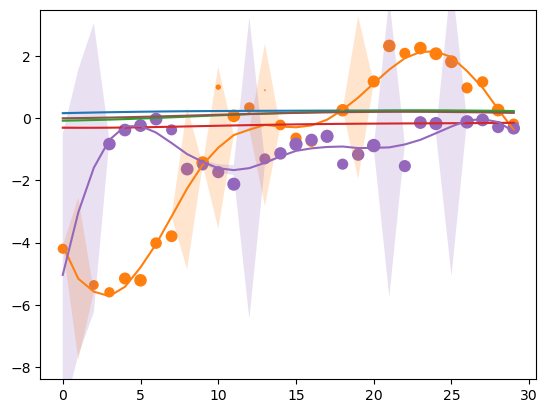

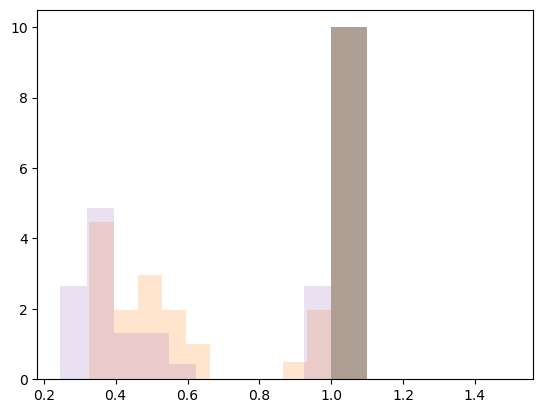

Epoch 13/2000: Training Loss = 0.176973, Validation Loss = 0.061180


0it [00:00, ?it/s]

tensor(0.7434)
0.03149822726845741 0.15636345744132996


2it [00:00,  4.33it/s]

tensor(0.7421)
0.02580614946782589 0.15023565292358398
tensor(0.7391)
0.03171106055378914 0.1656625121831894


...

tensor(0.7369)
0.03124449960887432 0.1369609832763672


4it [00:01,  3.49it/s]

tensor(0.7436)
0.03257472440600395 0.1621982455253601


6it [00:01,  3.86it/s]


tensor(0.7383)
0.02843181975185871 0.138549342751503
tensor(0.7413)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7427)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7452)
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])
tensor(0.6965)


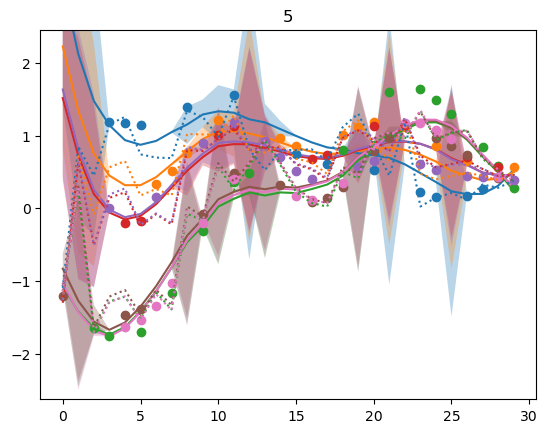

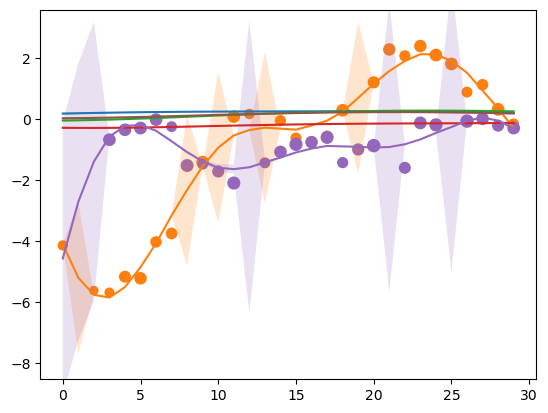

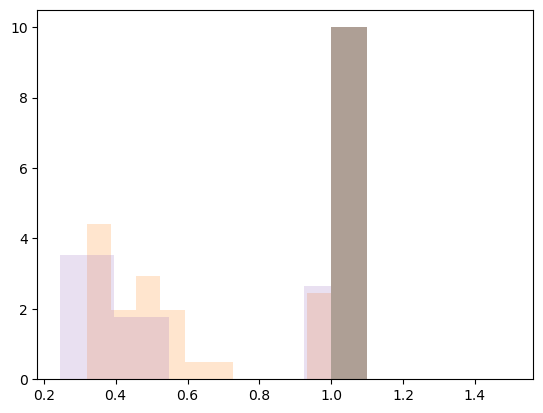

Epoch 14/2000: Training Loss = 0.170451, Validation Loss = 0.053862


0it [00:00, ?it/s]

tensor(0.7390)
0.03172533959150314 0.14757506549358368


1it [00:00,  2.89it/s]

tensor(0.7402)
0.02723124995827675 0.15809103846549988


...

tensor(0.7405)
0.0311500933021307 0.13425473868846893


4it [00:01,  3.45it/s]

tensor(0.7409)
0.0317106619477272 0.15037822723388672


6it [00:01,  3.70it/s]


tensor(0.7394)
0.027885258197784424 0.1439494639635086
tensor(0.7420)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7408)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7427)
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])
tensor(0.6962)


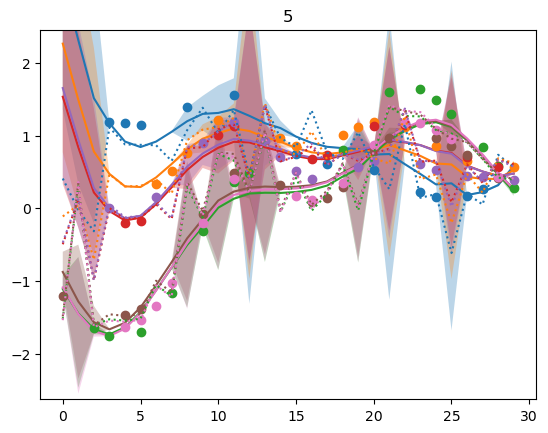

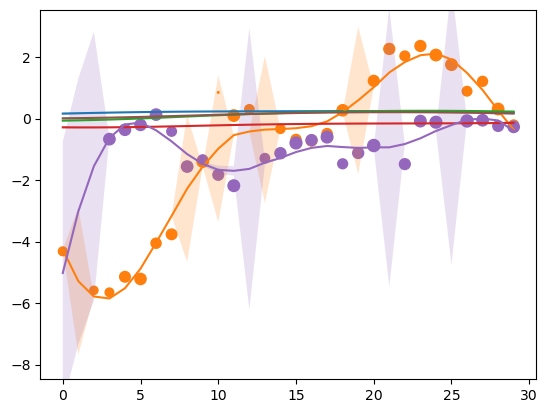

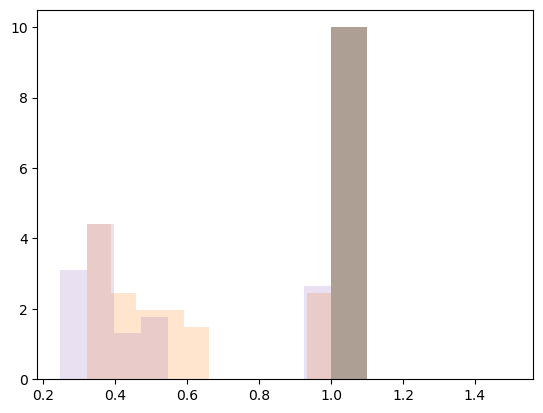

Epoch 15/2000: Training Loss = 0.167766, Validation Loss = 0.052404


0it [00:00, ?it/s]

tensor(0.7374)


1it [00:00,  2.47it/s]

0.029791032895445824 0.13052260875701904
tensor(0.7390)


...

0.026959581300616264 0.13329973816871643
tensor(0.7414)


5it [00:01,  4.11it/s]

0.03245649114251137 0.1493617594242096
tensor(0.7393)
0.029113393276929855 0.15208235383033752


6it [00:01,  3.97it/s]


tensor(0.7437)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7397)
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
tensor(0.7369)
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])
tensor(0.6965)


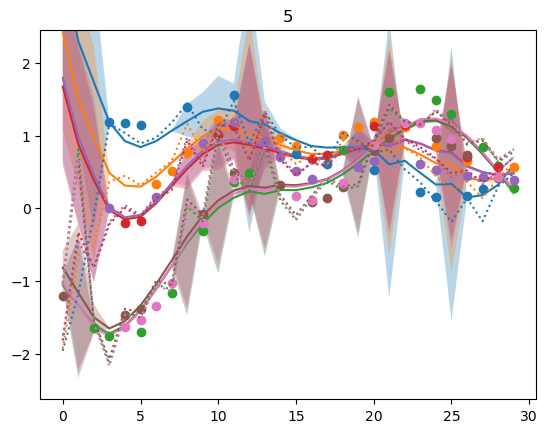

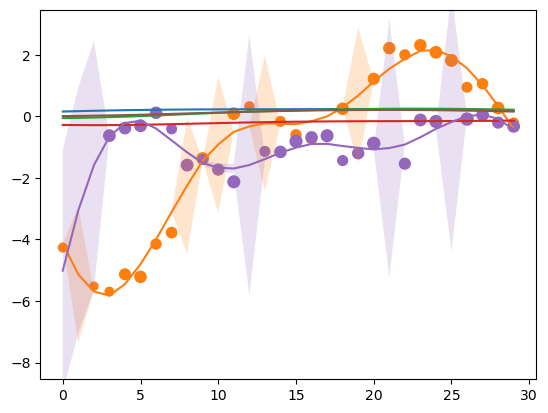

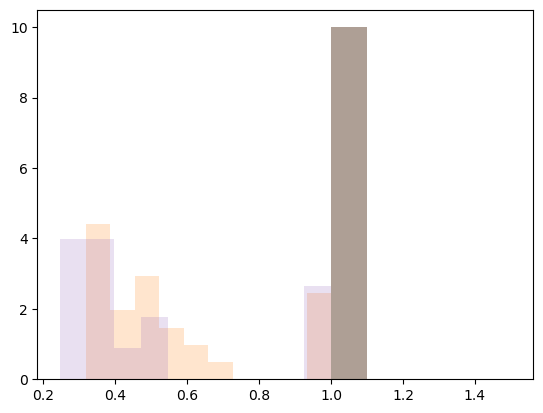

Epoch 16/2000: Training Loss = 0.161254, Validation Loss = 0.050643


0it [00:00, ?it/s]

tensor(0.7430)
0.029039716348052025 0.13120804727077484


0it [00:00, ?it/s]
2026-03-09 13:55:15 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...
2026-03-09 13:55:15 [INFO]: Finished training. The best model is from epoch#15.


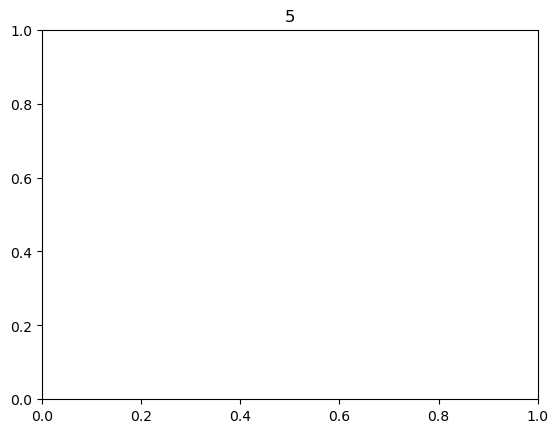

In [14]:
gpuae.model.backbone.alpha = 1e0
gpuae.model.gp.use_quantile = True
gpuae.model.gp.alpha = .8
gpuae.model.alpha = .8
gpuae.model.gp.thresholds = [0.8] * 10


gpuae.fit(dataset_train_nan, dataset_val_nan, train_kernel_only = True)  # train the model on the dataset

## Plot latent RPZ

In [8]:
def plot_multi_gaussian(q, i = 0, alpha = 1.96, linestyle = '-'):
    """
    Plot all dimensions of the ith observation
    """
    
    mu, var = np.array(q.mean.detach().numpy())[i], np.array(q.variance.detach().numpy())[i]**.5

    plt.plot(mu, linestyle = linestyle);
   
    plt.gca().set_prop_cycle(None)
    for j in range(var.shape[-1]):
        low, up = (mu - alpha*var)[:,j], (mu + alpha*var)[:,j]
        plt.fill_between(np.arange(mu.shape[0]), low, up, alpha = .2);

def plot_reconstructions(X, X_ori, q, model, i = 0, n_samples = 100, ax = None):
    """
    Given the observed data X, the latent distribution q and the model (for the decoder) plots the reconstructions
    """

    z = q.rsample((n_samples,))
    #print(z[0,0,0])
    #print(z[1,0,0])
    #print('**')
    #z = q.mean.repeat((100,1,1,1))

    #print(z.shape, X.shape)

    X_recon = np.array(model.model.backbone.decoder(z).mean.detach().numpy())[:,i]

    if ax is None:
        fig, ax = plt.subplots(figsize=(18,8))

    # plot X
    X = np.array(X.detach().numpy())
    X_ori = np.array(X_ori.detach().numpy())

    X[X==0] = np.nan
    ax.plot(X[i], 'o');
    ax.set_prop_cycle(None)
    ax.plot(X_ori[i], '+');
    ax.set_prop_cycle(None)

    #for j in range(n_samples):
    #    ax.plot(X_recon[j], alpha = .05)
    #    ax.set_prop_cycle(None)
    low, up = X_recon.min(axis=0), X_recon.max(axis=0)
    for j in range(X_recon.shape[-1]):
        ax.fill_between(np.arange(X.shape[1]), low[:,j], up[:,j], alpha = .3)

    ax.set_prop_cycle(None)
    ax.plot(X_recon.mean(axis=0))

    scale_factor = 1.5
    ymin, ymax = np.nanmin(X[i])*scale_factor, np.nanmax(X[i])*scale_factor
    ax.set_ylim([ymin,ymax])
    

In [9]:
import numpy as np
import matplotlib.pyplot as plt

i = 3
alpha = .5

X_ori = torch.tensor(dataset_val_nan['X_ori']).float()

X_corr = torch.tensor(dataset_val_nan['X']).float()
X_corr[X_corr!=X_corr] = 0.

qz_x_corr = gpuae.model.backbone.encoder(X_corr)

# correct
kernel_params = gpuae.gp.update_kernel_params(X_corr)
qz_star = gpuae.gp.correct_qz_x_with_gp(qz_x_corr, kernel_params)

# plot reconstructions

kernel_params = gpuae.gp.update_kernel_params(X_corr)
qz_star = gpuae.gp.correct_qz_x_with_gp(qz_x_corr, kernel_params)

plot_multi_gaussian(qz_x_corr, alpha = 1)
plot_multi_gaussian(qz_star, alpha = 1, linestyle = ':')
plt.show();

fig, ax = plt.subplots(2, figsize=(18,8))

i = 4
plot_reconstructions(X_corr, X_ori, qz_star, gpuae, ax = ax[1], i = i)
plot_reconstructions(X_corr, X_ori, qz_x_corr, gpuae, ax = ax[0], i = i)


AttributeError: 'ProbabilisticGP' object has no attribute 'use_quantile'

In [ ]:
# plot reconstructions

kernel_params = gpuae.gp.update_kernel_params(X_corr)
qz_star = gpuae.gp.correct_qz_x_with_gp(qz_x_corr, kernel_params)

plot_multi_gaussian(qz_x_corr, alpha = 1)
plot_multi_gaussian(qz_star, alpha = 1, linestyle = ':')
plt.show();

fig, ax = plt.subplots(2, figsize=(18,8))

i = 4
plot_reconstructions(X_corr, X_ori, qz_star, gpuae, ax = ax[1], i = i)
plot_reconstructions(X_corr, X_ori, qz_x_corr, gpuae, ax = ax[0], i = i)


In [ ]:
latent_variances = qz_x_corr.variance.reshape(-1,qz_x_corr.variance.shape[-1])
torch.quantile(latent_variances,q=0.1,dim=0)

In [ ]:
import torch
import torch.nn as nn

class NeuralNetwork(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(latent_dim, latent_dim),
            nn.Sigmoid()        
            )

    def forward(self, x, q = 1e-5):
        x_shape = x.shape
        x = x.reshape(-1,self.latent_dim)
        mask_below_quantile = (x<=q)
        logits = torch.zeros(x.shape)
        logits[~mask_below_quantile] = self.linear_relu_stack(x[~mask_below_quantile])
        #logits = self.linear_relu_stack(x)
        #logits[mask_below_quantile] = logits[mask_below_quantile] * 0
        logits = logits.reshape(x_shape)
        return logits.clamp(max = 1)

class OneDimensionNeuralNetwork(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(latent_dim, latent_dim),
            nn.ReLU()        
            )

    def forward(self, x, q = 1e-5):
        x_shape = x.shape
        x = x.reshape(-1,self.latent_dim)
        mask_above_quantile = (x>q)[:,0]
        logits = torch.zeros(x.shape) + 1e-6
        logits[mask_above_quantile] = self.linear_relu_stack(x[mask_above_quantile]).clamp(min = 1e-5, max = 10)
        #logits = self.linear_relu_stack(x)
        #logits[mask_below_quantile] = logits[mask_below_quantile] * 0
        logits = logits.reshape(x_shape)
        return logits

class VarianceCorrection(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.nns = [OneDimensionNeuralNetwork(1) for i in range(latent_dim)]

    def forward(self, x):
        x_shape = x.shape
        x = x.reshape(-1,self.latent_dim) #/ 1e-6
        logits = torch.vstack([self.nns[i](x[:,i]) for i in range(self.latent_dim)])
        logits = logits.reshape(x_shape)
        return logits.clamp(max = 1)
#gpuae.model.gp.nn = NeuralNetwork(latent_dim = 6)
gpuae.model.gp.nn = VarianceCorrection(latent_dim = 6)

In [ ]:
for i in range(qz_x_corr.variance.shape[-1]):
    plt.title('Histogram of variances outputed by a UAE for a given latent dimension')
    plt.hist(qz_x_corr.variance[:,:,i].flatten().detach().numpy(), bins = 50)
    plt.show();

In [ ]:
torch.quantile(qz_x_corr.variance[:,:,0].flatten(), q = 0.5)

In [ ]:
## learn_quantiles:

X_corr = torch.tensor(dataset_train_nan['X']).float()
X_corr[X_corr!=X_corr] = 0.

qz_x_corr = gpuae.model.backbone.encoder(X_corr)
z_var = qz_x_corr.variance

In [ ]:
plt.hist(z_var_reshaped[:,4].detach().numpy(), bins = 100);

In [ ]:
latent_dim = 6
z_var_reshaped = z_var.reshape(-1,latent_dim)
z_var_quantiles = torch.quantile(z_var_reshaped, q = 0.1, interpolation = 'higher', dim = 0)[None]
print(z_var_reshaped.shape)
z_var_reshaped = (z_var_reshaped >= z_var_quantiles).float()
print(z_var_reshaped.mean(axis=0))
latent_variances = z_var_reshaped.reshape(z_var.shape)

In [ ]:
import numpy as np
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
from scipy.optimize import fsolve

# Simulated z_var for demonstration (replace this with actual input)
#n_obs, n_time_steps, n_latent_dims = 100, 50, 8
#np.random.seed(0)
#z_var = np.abs(np.random.randn(n_obs, n_time_steps, n_latent_dims)) * 0.1

# Function to compute thresholds per latent dimension using GMM
def compute_gmm_thresholds(z_var):
    n_latent_dims = z_var.shape[2]
    thresholds = []

    for dim in range(n_latent_dims):
        variances = z_var[:, :, dim].reshape(-1, 1).detach().numpy()  # Flatten to (n_samples, 1)
        
        # Fit GMM
        gmm = GaussianMixture(n_components=2, random_state=0).fit(variances)
        means = gmm.means_.flatten()
        covs = gmm.covariances_.flatten()
        weights = gmm.weights_.flatten()

        # Solve for intersection
        def diff(x):
            return (weights[0] * norm.pdf(x, means[0], np.sqrt(covs[0])) -
                    weights[1] * norm.pdf(x, means[1], np.sqrt(covs[1])))

        try:
            initial_guess = np.mean(means)
            tau = fsolve(diff, x0=initial_guess)[0]
        except Exception:
            tau = np.percentile(variances, 30)  # fallback
            print('percentile instead')

        thresholds.append(tau)
    
    return torch.tensor(thresholds)

z_var = qz_x_corr.variance
thresholds_gmm = compute_gmm_thresholds(z_var)
thresholds_gmm


In [ ]:
gpuae.model.gp.thresholds = thresholds_gmm

In [ ]:
#gpuae.model.backbone.alpha = 1e0
#gpuae.gp.p = 0.1

gpuae.model.backbone.encoder.eval()
gpuae.model.backbone.decoder.eval()
gpuae.model.gp.use_quantile = True
gpuae.model.alpha = .8

gpuae.fit(dataset_train_nan, dataset_val_nan, train_kernel_only = True)  # train the model on the dataset

In [ ]:
from pypots.utils.metrics import calc_mae
import numpy as np

results = gpuae.predict(dataset_val_nan, with_gp = False)
imputation = np.array(results['imputation'])
calc_mae(imputation, dataset_val_nan['X_ori'], (dataset_val_nan['X_ori']==dataset_val_nan['X_ori']))

In [ ]:
import matplotlib.pyplot as plt

i = 1
plt.plot(imputation[i],':');
plt.gca().set_prop_cycle(None)
plt.plot(dataset_val_nan['X_ori'][i],'+');
plt.gca().set_prop_cycle(None)
plt.plot(dataset_val_nan['X'][i],'o');

In [ ]:
import matplotlib.pyplot as plt

for j in gpuae.gp.kernel_params_history.keys():
    hist_j = gpuae.gp.kernel_params_history[j]
    fig, ax = plt.subplots(2, figsize=(18,8), sharex = True)
    for elt in ['a','b','c','d']:
        ax[0].plot(hist_j[elt], label = elt)
    ax[1].semilogy(hist_j['e'])
    fig.legend();
    plt.title(f'Latent dim {j}')
    plt.show();

In [ ]:
torch.save(gpuae.model.backbone.encoder.state_dict().copy(), 'encoder_uae')
torch.save(gpuae.model.backbone.decoder.state_dict().copy(), 'decoder_uae')

In [ ]:
state_dict = torch.load('encoder_uae');
gpuae.model.backbone.encoder.load_state_dict(state_dict);
state_dict = torch.load('decoder_uae');
gpuae.model.backbone.decoder.load_state_dict(state_dict);